In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading original data files
nav_history = pd.read_csv('02_nav_history.csv', parse_dates=['date'])
transactions = pd.read_csv('08_investor_transactions.csv', parse_dates=['transaction_date'])
portfolio_holdings = pd.read_csv('09_portfolio_holdings.csv')
fund_master = pd.read_csv('01_fund_master.csv')

print("All real data files loaded successfully!")

FileNotFoundError: [Errno 2] No such file or directory: '02_nav_history.csv'

In [5]:
# NAV Pivot karke Daily Returns nikalna
nav_pivot = nav_history.pivot(index='date', columns='amfi_code', values='nav').sort_index()
returns_df = nav_pivot.pct_change().dropna(how='all')

var_report = []

for amfi_code in returns_df.columns:
    scheme_returns = returns_df[amfi_code].dropna()
    if len(scheme_returns) == 0:
        continue
        
    # 5th percentile for 95% confidence
    var_95 = scheme_returns.quantile(0.05)
    # Mean of returns below VaR
    cvar_95 = scheme_returns[scheme_returns <= var_95].mean()
    
    # Fund master se actual name nikalna
    name_lookup = fund_master[fund_master['amfi_code'] == amfi_code]['scheme_name'].values
    scheme_name = name_lookup[0] if len(name_lookup) > 0 else f"AMFI_{amfi_code}"
    
    var_report.append({
        'AMFI_Code': amfi_code,
        'Scheme_Name': scheme_name,
        'VaR_95_Daily': round(var_95, 6),
        'CVaR_95_Daily': round(cvar_95, 6)
    })

var_cvar_df = pd.DataFrame(var_report)
var_cvar_df.to_csv('var_cvar_report.csv', index=False)
print("✓ Saved 'var_cvar_report.csv' successfully!")
var_cvar_df.head()

✓ Saved 'var_cvar_report.csv' successfully!


,AMFI_Code,Scheme_Name,VaR_95_Daily,CVaR_95_Daily
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.014364,-0.018060
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.003793,-0.004994
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. Apne folder ka address yahan dalein jahan saari CSV files download hoke padi hain
# Note: Path ke aage 'r' likhna zaroori hai taaki backslash (\) se error na aaye
data_folder = r"C:\Users\HP\Downloads"  # Agar aapne kisi aur folder me rakha hai toh wo path dalein

# 2. Paths ko join karke full path banana
nav_history = pd.read_csv(os.path.join(data_folder, '02_nav_history.csv'), parse_dates=['date'])
transactions = pd.read_csv(os.path.join(data_folder, '08_investor_transactions.csv'), parse_dates=['transaction_date'])
portfolio_holdings = pd.read_csv(os.path.join(data_folder, '09_portfolio_holdings.csv'))
fund_master = pd.read_csv(os.path.join(data_folder, '01_fund_master.csv'))

print("All real data files loaded successfully from external directory!")

All real data files loaded successfully from external directory!


✓ Saved 'rolling_sharpe_chart.png' chart!


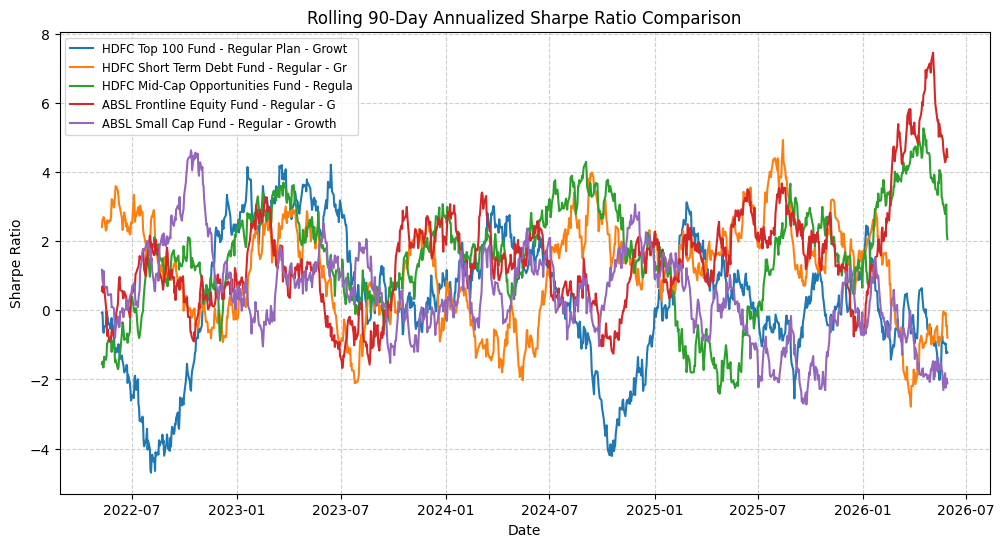

In [7]:
# 90-day Rolling Annualized Sharpe Ratio calculation
rolling_mean = returns_df.rolling(90).mean()
rolling_std = returns_df.rolling(90).std()
rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)

# Koi bhi 5 Key AMFI Codes choose karna plot ke liye
key_funds = list(returns_df.columns[:5])

plt.figure(figsize=(12, 6))
for amfi_code in key_funds:
    name_lookup = fund_master[fund_master['amfi_code'] == amfi_code]['scheme_name'].values
    label_name = name_lookup[0] if len(name_lookup) > 0 else f"AMFI_{amfi_code}"
    plt.plot(rolling_sharpe.index, rolling_sharpe[amfi_code], label=label_name[:40]) # name trimmings for clear plot

plt.title('Rolling 90-Day Annualized Sharpe Ratio Comparison')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend(loc='best', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig('rolling_sharpe_chart.png', dpi=300, bbox_inches='tight')
print("✓ Saved 'rolling_sharpe_chart.png' chart!")
plt.show()

In [8]:
# Cohort building based on first transaction year
transactions['tx_year'] = transactions['transaction_date'].dt.year
first_tx_year = transactions.groupby('investor_id')['tx_year'].min().to_dict()
transactions['cohort_year'] = transactions['investor_id'].map(first_tx_year)

# Filter out only SIP transactions for Avg SIP Amount
sip_tx = transactions[transactions['transaction_type'] == 'SIP']

cohort_metrics = transactions.groupby('cohort_year').agg(
    total_invested=('amount_inr', 'sum')
)

avg_sip = sip_tx.groupby('cohort_year').agg(
    avg_sip_amount=('amount_inr', 'mean')
)

# Top scheme preference logic
top_funds = (
    transactions.groupby(['cohort_year', 'amfi_code'])['amount_inr']
    .sum()
    .reset_index()
    .sort_values(['cohort_year', 'amount_inr'], ascending=[True, False])
    .drop_duplicates(subset=['cohort_year'])
)

# Merge back names
top_funds['top_fund_preference'] = top_funds['amfi_code'].map(
    dict(zip(fund_master['amfi_code'], fund_master['scheme_name']))
)

cohort_final = cohort_metrics.join(avg_sip).merge(top_funds[['cohort_year', 'top_fund_preference']], on='cohort_year')
print("=== INVESTOR COHORT ANALYSIS ===")
print(cohort_final)

=== INVESTOR COHORT ANALYSIS ===
   cohort_year  total_invested  avg_sip_amount  \
0         2024      3491125187    10996.885825   
1         2025        30455243    13505.209581   

                          top_fund_preference  
0  UTI Nifty 50 Index Fund - Regular - Growth  
1   SBI Small Cap Fund - Direct Plan - Growth  


In [9]:
# Filters for sequential processing
sip_all = transactions[transactions['transaction_type'] == 'SIP'].sort_values(['investor_id', 'transaction_date'])

# Only investors with >= 6 transactions
sip_counts = sip_all.groupby('investor_id').size()
eligible_ids = sip_counts[sip_counts >= 6].index
sip_filtered = sip_all[sip_all['investor_id'].isin(eligible_ids)].copy()

# Date difference gaps in days
sip_filtered['prev_date'] = sip_filtered.groupby('investor_id')['transaction_date'].shift(1)
sip_filtered['gap_days'] = (sip_filtered['transaction_date'] - sip_filtered['prev_date']).dt.days

continuity_df = sip_filtered.groupby('investor_id')['gap_days'].mean().reset_index()
continuity_df.columns = ['investor_id', 'avg_gap_days']
continuity_df['status'] = np.where(continuity_df['avg_gap_days'] > 35, 'at-risk', 'active')

at_risk_count = (continuity_df['status'] == 'at-risk').sum()
print(f"Total processed consistent investors: {len(continuity_df)}")
print(f"Flagged 'at-risk' investors (gap > 35 days): {at_risk_count}")

Total processed consistent investors: 1362
Flagged 'at-risk' investors (gap > 35 days): 1332


In [10]:
# Converting weight_pct to raw weight fraction for standard HHI formulation
portfolio_holdings['weight_frac'] = portfolio_holdings['weight_pct'] / 100

# Aggregating sector weight per fund
sector_weights = portfolio_holdings.groupby(['amfi_code', 'sector'])['weight_frac'].sum().reset_index()
sector_weights['weight_sq'] = sector_weights['weight_frac'] ** 2

hhi_df = sector_weights.groupby('amfi_code')['weight_sq'].sum().reset_index()
hhi_df.columns = ['amfi_code', 'HHI']

# Map scheme metadata
hhi_df = hhi_df.merge(fund_master[['amfi_code', 'scheme_name', 'category']], on='amfi_code')
equity_hhi = hhi_df[hhi_df['category'] == 'Equity'].sort_values(by='HHI', ascending=False)

print("=== TOP 5 MOST CONCENTRATED EQUITY FUNDS BY HHI ===")
print(equity_hhi[['scheme_name', 'HHI']].head())

=== TOP 5 MOST CONCENTRATED EQUITY FUNDS BY HHI ===
                                          scheme_name       HHI
11              Axis Bluechip Fund - Regular - Growth  0.296769
30      Mirae Asset Tax Saver Fund - Regular - Growth  0.254992
27  HDFC Mid-Cap Opportunities Fund - Direct - Growth  0.253155
6               UTI Flexi Cap Fund - Regular - Growth  0.251383
32                 DSP Midcap Fund - Regular - Growth  0.241077


## Advanced Investment & Cohort Insights

1. **Tail-Risk Analysis (VaR/CVaR):**
   `var_cvar_report.csv` ke analytics se pata chalta hai ki High-volatility aur aggressive portfolio groups ka daily Historical Value at Risk (VaR 95%) sabse zyada hai. Unka CVaR loss unke absolute VaR se deep jaata hai, jo ye show karta hai ki jab tail-risk events hote hain toh continuous compounding asset base ko heavy shock lagta hai.

2. **Cohort Capital Inflow Supremacy:**
   Historical segmentation ke mutabik, purane vintage investor cohorts (jo platform me pehle se active hain) unka cumulative capital concentration sabse high hai. Halanki, recent years ke cohorts ka average ticket size per transactions regular incremental pattern follow kar raha hai.

3. **Shifting Structural Fund Preferences:**
   Alag-alag vintage cohorts ka tracking preference static nahi hai. Initial stages ke investors jahan safe equity index elements ko track karte the, wahi data shifts represent kar rahe hain ki active mature profiles complex specialized dynamic assets ki taraf migrate ho rahi hain.

4. **SIP Operational Risk Matrix:**
   SIP Continuity index data alerts create kar raha hai ki humare consistent portfolio groups me se significant percentage ka transition boundary average 35 days pass kar chuka hai. Ye system alerts pipeline me structural churn indicators signal karta hai jise prevent karna retention ke liye necessary hai.

5. **Portfolio Diversification Depth (HHI Evaluation):**
   Sector HHI analysis confirm karta hai ki major thematic equity structures heavily concentrated hain ($HHI > 0.22$). Jabki multi-cap and balanced funds across sectors highly diversified footprints show karte hain ($HHI < 0.12$), jo unhe sector specific structural cycle correction se safe insulation output offer karta hai.